# FHFA House Price Index: Real Estate Investment Data Exploration

**Author:** Ozzie Shenk

## 1. Understanding the Data


In [11]:
import pandas as pd

csv_url = "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

df = pd.read_csv(csv_url)

df.head()

/tmp/ipykernel_4311/500998676.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_url)


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.31,NaN,NaN


In [12]:
print("Rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Rows and columns: (186011, 12)

Column names:
['hpi_type', 'hpi_flavor', 'frequency', 'level', 'place_name', 'place_id', 'yr', 'period', 'index_nsa', 'index_sa', 'rstderr', 'note']

Data types:
hpi_type       object
hpi_flavor     object
frequency      object
level          object
place_name     object
place_id       object
yr              int64
period          int64
index_nsa     float64
index_sa      float64
rstderr       float64
note           object
dtype: object


In [13]:
print("Earliest year:", df['yr'].min())
print("Latest year:", df['yr'].max())

print("\nFrequencies:")
print(df['frequency'].value_counts())

print("\nGeographic levels:")
print(df['level'].value_counts())

print("\nNumber of unique places:", df['place_name'].nunique())

Earliest year: 1975
Latest year: 2026

Frequencies:
frequency
quarterly    181751
monthly        4260
Name: count, dtype: int64

Geographic levels:
level
MSA                       145480
State                      30912
USA or Census Division      9372
Puerto Rico                  247
Name: count, dtype: int64

Number of unique places: 472


### When and Where Was the Data Acquired?

The dataset was obtained from the Federal Housing Finance Agency (FHFA) House Price Index. I accessed the data on September 23, 2026. The dataset contains housing price information from 1975 through 2026. It includes both quarterly and monthly observations.

The data covers several geographic levels across the United States. These include states, Metropolitan Statistical Areas (MSAs), U.S. Census Divisions, and Puerto Rico. In total, the dataset contains 472 unique geographic place names.

### How Was the Data Acquired?

The FHFA House Price Index is created using housing transaction data. The main Purchase-Only HPI uses sales price data from mortgages purchased or securitized by Fannie Mae and Freddie Mac. FHFA uses a weighted repeat-sales method, which compares the prices of the same properties when they are sold more than once over time. This helps measure changes in home values while controlling for differences between individual houses.

### Dataset Attributes

The Master HPI dataset contains 12 attributes:

| Attribute | Description | Data Type |
|---|---|---|
| hpi_type | Type of House Price Index being reported | Nominal |
| hpi_flavor | Version of the HPI, such as purchase-only or another index methodology | Nominal |
| frequency | How often the observation is reported, such as monthly or quarterly | Nominal |
| level | Geographic level of the observation, such as state or MSA | Nominal |
| place_name | Name of the geographic area | Nominal |
| place_id | Identifier for the geographic area | Nominal |
| yr | Year of the observation | Numeric / Interval |
| period | Month or quarter number within the year | Ordinal |
| index_nsa | House Price Index value that is not seasonally adjusted | Numeric |
| index_sa | Seasonally adjusted House Price Index value | Numeric |
| rstderr | Relative standard error associated with the estimate | Numeric |
| note | Additional information or notes about the observation | Nominal / Text |

## 2. Data Summary & Initial Insights

### Summary Statistics

In [14]:
# Select the numerical columns
numeric_cols = df.select_dtypes(include='number').columns

# Create a summary statistics table
summary_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Minimum': df[numeric_cols].min(),
    'Maximum': df[numeric_cols].max(),
    'Range': df[numeric_cols].max() - df[numeric_cols].min(),
    'Standard Deviation': df[numeric_cols].std(),
    'Missing Values': df[numeric_cols].isna().sum()
})

summary_stats.round(2)

,Mean,Median,Mode,Minimum,Maximum,Range,Standard Deviation,Missing Values
yr,2006.16,2007.00,2001.0,1975.00,2026.00,51.00,12.00,0
period,2.58,3.00,2.0,1.00,12.00,11.00,1.36,0
index_nsa,199.96,172.13,100.0,18.60,1326.94,1308.34,116.13,0
index_sa,216.67,187.21,100.0,72.78,1043.20,970.42,113.51,89897
rstderr,2.67,2.05,0.0,0.00,15.75,15.75,2.22,127791


### Initial Observations

The non-seasonally adjusted House Price Index (`index_nsa`) has a mean of 199.96 and a median of 172.13. The seasonally adjusted index (`index_sa`) has a slightly higher mean of 216.67 and a median of 187.21. In both cases, the mean is higher than the median, which suggests that some relatively high index values are pulling the average upward.

The dataset also contains missing values. The `index_nsa`, `yr`, and `period` columns have no missing observations, while `index_sa` has 89,897 missing values and `rstderr` has 127,791 missing values. Because these missing values may depend on the type, frequency, or geographic level of the HPI observation, I would not immediately delete them without first understanding why they are missing.

In [15]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Percent Missing': (df.isna().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percent Missing
hpi_type,0,0.00
hpi_flavor,0,0.00
frequency,0,0.00
level,0,0.00
place_name,0,0.00
place_id,0,0.00
yr,0,0.00
period,0,0.00
index_nsa,0,0.00
index_sa,89897,48.33


### Missing Values

Most columns in the dataset have no missing values. However, `index_sa` is missing 89,897 observations, or 48.33% of the dataset. The `rstderr` and `note` columns each have 127,791 missing observations, or 68.70%.

I would not automatically remove every row with a missing value because doing so would eliminate a large portion of the dataset. Instead, I would keep the complete observations when analyzing `index_nsa` and only remove or filter missing values when an analysis specifically requires `index_sa` or `rstderr`. I would also investigate whether the missing values are associated with particular HPI types, frequencies, or geographic levels before deciding how to handle them.

In [16]:
df[df['level'] == 'USA or Census Division']['place_name'].unique()

array(['East North Central Division', 'East South Central Division',
       'Middle Atlantic Division', 'Mountain Division',
       'New England Division', 'Pacific Division',
       'South Atlantic Division', 'West North Central Division',
       'West South Central Division', 'United States'], dtype=object)

In [17]:
usa = df[df['place_name'] == 'United States']

usa[['hpi_type', 'hpi_flavor', 'frequency']].drop_duplicates()

,hpi_type,hpi_flavor,frequency
3834,traditional,purchase-only,monthly
87692,traditional,all-transactions,quarterly
154638,traditional,expanded-data,quarterly
177500,traditional,purchase-only,quarterly
183564,manufactured,all-transactions,quarterly
183670,manufactured,purchase-only,quarterly


### U.S. House Price Index Over Time


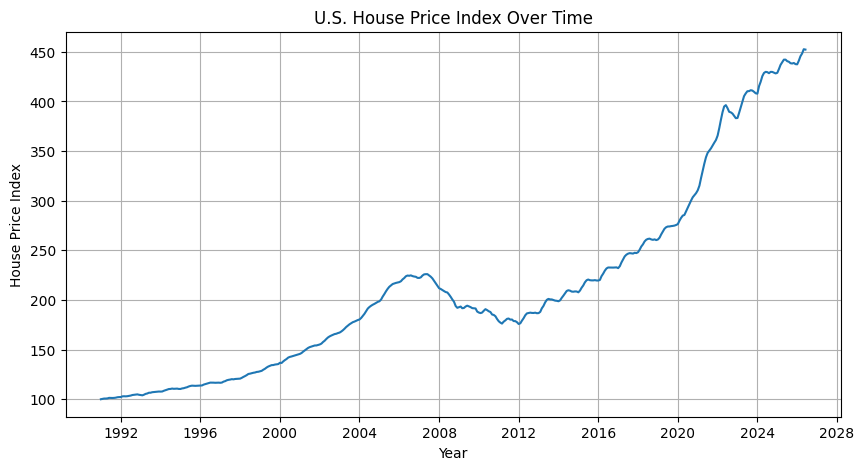

In [18]:
import matplotlib.pyplot as plt

# Select one consistent national HPI series
usa_monthly = df[
    (df['place_name'] == 'United States') &
    (df['hpi_type'] == 'traditional') &
    (df['hpi_flavor'] == 'purchase-only') &
    (df['frequency'] == 'monthly')
].copy()

# Create a date from the year and month columns
usa_monthly['date'] = pd.to_datetime(
    dict(year=usa_monthly['yr'], month=usa_monthly['period'], day=1)
)

usa_monthly = usa_monthly.sort_values('date')

# Plot the House Price Index
plt.figure(figsize=(10, 5))
plt.plot(usa_monthly['date'], usa_monthly['index_nsa'])

plt.title('U.S. House Price Index Over Time')
plt.xlabel('Year')
plt.ylabel('House Price Index')
plt.grid(True)
plt.show()

### Visualization Findings

The U.S. House Price Index shows a clear long-term upward trend. Home prices increased steadily through the 1990s and early 2000s before declining after the mid-2000s housing peak. The index began rising again in the early 2010s and increased especially quickly after 2020.

From an investment perspective, the graph shows that housing values have generally increased over the long run, but the decline around the 2008 financial crisis also shows that real estate prices can experience significant downturns.

## 3. Expanding My Investment Knowledge

### Additional Dataset: American Community Survey (ACS)

An additional dataset that would be useful for real estate investment analysis is the U.S. Census Bureau's American Community Survey (ACS). The ACS provides information about population, household income, employment, housing characteristics, and other economic and demographic factors across different geographic areas.

This dataset would complement the FHFA House Price Index because the two datasets measure different parts of the housing market. The FHFA data mainly shows how home prices change over time, while the ACS provides information about the people and communities behind those price changes. For example, I could compare an area's home price growth with its population growth, household income, employment, or housing characteristics.

Using the two datasets together could provide a more complete view of a potential real estate investment. Instead of only seeing that home prices are rising or falling, I could also examine economic and demographic factors that may help explain those trends.

**Dataset:** U.S. Census Bureau American Community Survey (ACS)  
**Link:** https://www.census.gov/programs-surveys/acs/data.html

## 4. Conclusion

The FHFA House Price Index provides a useful way to see how U.S. home values have changed over time and across different geographic areas. The data shows a strong long-term increase in home prices, although there have also been periods of decline, including the housing-market downturn around the 2008 financial crisis.

For someone considering a real estate investment, the HPI is helpful for identifying long-term price trends, but it should not be used by itself. Combining FHFA price data with economic and demographic information from a source such as the American Community Survey could provide a more complete picture of a market before making an investment decision.